# Week 2 Lab: Diagnostic Forensics

**ECBS5200 — Practical Deep Learning Engineering**

You receive 4 pre-trained ModernBERT models. All trained on the same data,
same architecture — but with different training configurations. Your job:
evaluate them, examine the training curves, and figure out what produced
each one.

**Time budget:** ~80 minutes.

Some models are good. Some have problems. Figure out which is which.

## Kaggle setup (do this first!)

1. **Persistence** → "Variables and Files"
2. **Internet** → On
3. **Accelerator** → GPU T4

In [2]:
import subprocess, sys, os
import dotenv

# HuggingFace config — set BEFORE importing HF libraries
# If not set, load it from `.env` file
if os.path.exists('/kaggle/working'):
    os.environ['HF_HOME'] = '/kaggle/working/.hf_cache'
else:
    dotenv.load_dotenv(dotenv.find_dotenv())
os.environ['HF_HUB_DOWNLOAD_TIMEOUT'] = '120'
os.environ['HF_HUB_ETAG_TIMEOUT'] = '60'
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '0'

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet",
    "transformers>=4.53", "datasets", "accelerate", "scikit-learn",
    "matplotlib", "pandas", "tqdm",
])
print("Packages installed.")

from huggingface_hub import login
hf_token = None
try:
    from kaggle_secrets import UserSecretsClient
    hf_token = UserSecretsClient().get_secret("HF_TOKEN")
except Exception:
    pass
if not hf_token:
    try:
        from google.colab import userdata
        hf_token = userdata.get("HF_TOKEN")
    except Exception:
        pass
if not hf_token:
    hf_token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")
if hf_token:
    login(token=hf_token)
    print("Logged in to HuggingFace.")
else:
    print("WARNING: No HF_TOKEN found. May hit rate limits.")

Packages installed.


In [3]:
import gc
import json
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.amp import autocast
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

# Load course utilities
REPO_PATH = Path("../..").resolve()
if not (REPO_PATH / "utils" / "data_utils.py").exists():
    REPO_PATH = Path("/tmp/course")
    if not REPO_PATH.exists():
        subprocess.check_call(["git", "clone", "--depth", "1",
            "https://github.com/earino/applied-deep-learning.git", str(REPO_PATH)])
sys.path.insert(0, str(REPO_PATH))

from utils.data_utils import (
    load_course_data, LABEL_LIST, NUM_LABELS, LABEL_TO_ID, ID_TO_LABEL, MAX_LENGTH,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    cc = torch.cuda.get_device_capability()
    AMP_DTYPE = torch.bfloat16 if cc[0] >= 8 else torch.float16
else:
    AMP_DTYPE = torch.float32

print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU:    {torch.cuda.get_device_name(0)}")
print(f"AMP:    {AMP_DTYPE}")

Device: cuda
GPU:    Tesla T4
AMP:    torch.float16


---
## Part 1: Load Data and Models (~8 min)
---

In [4]:
# GUIDED: Load and tokenize the validation set
print("Loading dataset...")
t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained("earino/ecbs5200-week2-alpha")
_, val_ds, _ = load_course_data(tokenizer=tokenizer, max_length=MAX_LENGTH)
print(f"  Val: {len(val_ds):,} examples ({time.time()-t0:.1f}s)")

# Also load raw text data for later inspection
_, val_ds_raw, _ = load_course_data(tokenizer=None)


class ComplaintDataset(Dataset):
    def __init__(self, hf_dataset):
        self.ds = hf_dataset

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        return {
            "input_ids": torch.tensor(item["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(item["attention_mask"], dtype=torch.long),
            "labels": torch.tensor(item["label"], dtype=torch.long),
        }


val_loader = DataLoader(ComplaintDataset(val_ds), batch_size=64, shuffle=False)

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Filter:   0%|          | 0/21439 [00:00<?, ? examples/s]

Map:   0%|          | 0/57846 [00:00<?, ? examples/s]

Map:   0%|          | 0/6430 [00:00<?, ? examples/s]

Map:   0%|          | 0/21432 [00:00<?, ? examples/s]

  Val: 6,430 examples (45.2s)


In [5]:
# GUIDED: Load the 4 mystery models from HuggingFace Hub
MODEL_REPOS = {
    "Alpha": "earino/ecbs5200-week2-alpha",
    "Bravo": "earino/ecbs5200-week2-bravo",
    "Charlie": "earino/ecbs5200-week2-charlie",
    "Delta": "earino/ecbs5200-week2-delta",
}

models = {}
for name, repo_id in MODEL_REPOS.items():
    print(f"Loading Model {name}...")
    t0 = time.time()
    models[name] = AutoModelForSequenceClassification.from_pretrained(
        repo_id, attn_implementation="sdpa",
    ).to(device)
    models[name].eval()
    print(f"  Loaded in {time.time()-t0:.1f}s")

print(f"\n4 models loaded. All are ModernBERT-base with 113-class heads.")
print(f"Same architecture, same data — different training configurations.")

Loading Model Alpha...


model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

  Loaded in 13.1s
Loading Model Bravo...


config.json: 0.00B [00:00, ?B/s]

...

  Loaded in 5.1s
Loading Model Delta...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

  Loaded in 4.9s

4 models loaded. All are ModernBERT-base with 113-class heads.
Same architecture, same data — different training configurations.


In [12]:
# GUIDED: Load training logs (per-epoch metrics for all 4 models)
from huggingface_hub import hf_hub_download

logs_path = hf_hub_download(
    repo_id="earino/ecbs5200-week2-alpha",
    filename="training_logs.json",
)
with open(logs_path) as f:
    training_logs = json.load(f)

for name in ["Alpha", "Bravo", "Charlie", "Delta"]:
    key = name.lower()
    n_epochs = len(training_logs[key]["epochs"])
    print(f"  Model {name}: {n_epochs} epoch(s) of training data")

training_logs.json: 0.00B [00:00, ?B/s]

  Model Alpha: 3 epoch(s) of training data
  Model Bravo: 15 epoch(s) of training data
  Model Charlie: 1 epoch(s) of training data
  Model Delta: 3 epoch(s) of training data


---
## Part 2: Evaluate All Models (~8 min)
---

In [6]:
# GUIDED: Evaluation function
def evaluate_model(model, loader):
    """Evaluate model, return metrics + predictions."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            with autocast("cuda", dtype=AMP_DTYPE, enabled=(device.type == "cuda")):
                logits = model(input_ids=ids, attention_mask=mask).logits
            all_preds.extend(logits.argmax(dim=-1).cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    preds, labels = np.array(all_preds), np.array(all_labels)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro", zero_division=0)
    zero_f1 = sum(1 for c in range(NUM_LABELS)
                  if f1_score(labels == c, preds == c, zero_division=0) == 0.0
                  and np.sum(labels == c) > 0)
    return {
        "accuracy": round(acc, 4),
        "macro_f1": round(f1, 4),
        "zero_f1_classes": zero_f1,
        "preds": preds,
        "labels": labels,
    }


results = {}
for name, model in models.items():
    print(f"Evaluating Model {name}...")
    t0 = time.time()
    results[name] = evaluate_model(model, val_loader)
    r = results[name]
    print(f"  acc={r['accuracy']:.4f}, f1={r['macro_f1']:.4f}, "
          f"zero_f1={r['zero_f1_classes']}, ({time.time()-t0:.1f}s)")

# Clean up GPU memory — we have the predictions, don't need the models loaded
for name in list(models.keys()):
    del models[name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\nModels unloaded to free GPU memory.")

Evaluating Model Alpha...


W0415 14:22:01.737000 4252 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


  acc=0.5022, f1=0.2162, zero_f1=39, (30.5s)
Evaluating Model Bravo...
  acc=0.4406, f1=0.1112, zero_f1=63, (18.8s)
Evaluating Model Charlie...
  acc=0.5252, f1=0.1374, zero_f1=62, (19.1s)
Evaluating Model Delta...
  acc=0.5537, f1=0.1985, zero_f1=49, (19.6s)

Models unloaded to free GPU memory.


---
## Part 3: Examine the Results (~8 min)

The `results` dict has accuracy, macro F1, zero-F1 class count, and
predictions for each model. Before we make a formatted table, dig into
the numbers yourself.
---

In [7]:
results

{'Alpha': {'accuracy': 0.5022,
  'macro_f1': 0.2162,
  'zero_f1_classes': 39,
  'preds': array([23, 10, 10, ..., 41, 39, 10]),
  'labels': array([100,  10,  10, ...,  67,  39,  56])},
 'Bravo': {'accuracy': 0.4406,
  'macro_f1': 0.1112,
  'zero_f1_classes': 63,
  'preds': array([23, 10, 10, ..., 78, 39, 10]),
  'labels': array([100,  10,  10, ...,  67,  39,  56])},
 'Charlie': {'accuracy': 0.5252,
  'macro_f1': 0.1374,
  'zero_f1_classes': 62,
  'preds': array([23, 10, 10, ..., 13, 52, 10]),
  'labels': array([100,  10,  10, ...,  67,  39,  56])},
 'Delta': {'accuracy': 0.5537,
  'macro_f1': 0.1985,
  'zero_f1_classes': 49,
  'preds': array([100,  10,  10, ...,  41,  52,  10]),
  'labels': array([100,  10,  10, ...,  67,  39,  56])}}

In [20]:
# Compute the accuracy-F1 gap (`accuracy - macro_f1`) for each model
for name, r in results.items():
    gap = r["accuracy"] - r["macro_f1"]
    print(f"Model {name}: Accuracy-F1 gap = {gap:.4f}")

# Print the lengths of the training preds and labels
for name, r in results.items():
    print(f"Model {name}: {len(r['preds'])} predictions, {len(r['labels'])} labels")

Model Alpha: Accuracy-F1 gap = 0.2860
Model Bravo: Accuracy-F1 gap = 0.3294
Model Charlie: Accuracy-F1 gap = 0.3878
Model Delta: Accuracy-F1 gap = 0.3552
Model Alpha: 6430 predictions, 6430 labels
Model Bravo: 6430 predictions, 6430 labels
Model Charlie: 6430 predictions, 6430 labels
Model Delta: 6430 predictions, 6430 labels


**Answer these by examining the `results` dict.** You can inspect any
model's metrics with `results["Alpha"]["accuracy"]`, etc.

1. Which model has the highest accuracy? Which has the highest macro F1?
   Are they the same model?

2. Which model has the most zero-F1 classes? How many?

3. Compute the accuracy-F1 gap (`accuracy - macro_f1`) for each model.
   Which model has the smallest gap? What might a small gap mean?

YOUR ANSWERS:

1. Delta has the highest accuracy and Alpha the highest macro F1.

2. Bravo, 63.

3. Alpha has the smallest gap. It might mean that classes with low frequency are weighted so they are taken more into account compared with other models.


In [9]:
# GUIDED: Now let's build the formatted comparison table for reference.
comparison_rows = []
for name in ["Alpha", "Bravo", "Charlie", "Delta"]:
    r = results[name]
    comparison_rows.append({
        "Model": name,
        "Accuracy": r["accuracy"],
        "Macro F1": r["macro_f1"],
        "Zero-F1 Classes": r["zero_f1_classes"],
        "Acc-F1 Gap": round(r["accuracy"] - r["macro_f1"], 4),
    })

comparison_df = pd.DataFrame(comparison_rows)
print("=" * 60)
print("COMPARISON TABLE")
print("=" * 60)
print(comparison_df.to_string(index=False))

COMPARISON TABLE
  Model  Accuracy  Macro F1  Zero-F1 Classes  Acc-F1 Gap
  Alpha    0.5022    0.2162               39      0.2860
  Bravo    0.4406    0.1112               63      0.3294
Charlie    0.5252    0.1374               62      0.3878
  Delta    0.5537    0.1985               49      0.3552


---
## Part 4: Predict Before You Plot

You have the numbers. Before looking at the training curves, make
predictions based on what the table tells you.
---

**Based ONLY on the comparison table above, answer these questions.
Write your predictions before running the next cells.**

1. Which model do you think trained for the most epochs? Why?

2. Which model do you think used class weighting? What's your evidence?

3. Which model do you think is undertrained? What makes you say that?

YOUR PREDICTIONS:

1. It might be Delta, the one with highest accuracy because it could mean low training error.

2. Alpha, because it has the smallest Acc-F1 gap.

3. Bravo, with Acc and macro F1 both being low.


---
## Part 5: Training Curves (~10 min)

Now let's see if the training curves confirm or contradict your predictions.
---

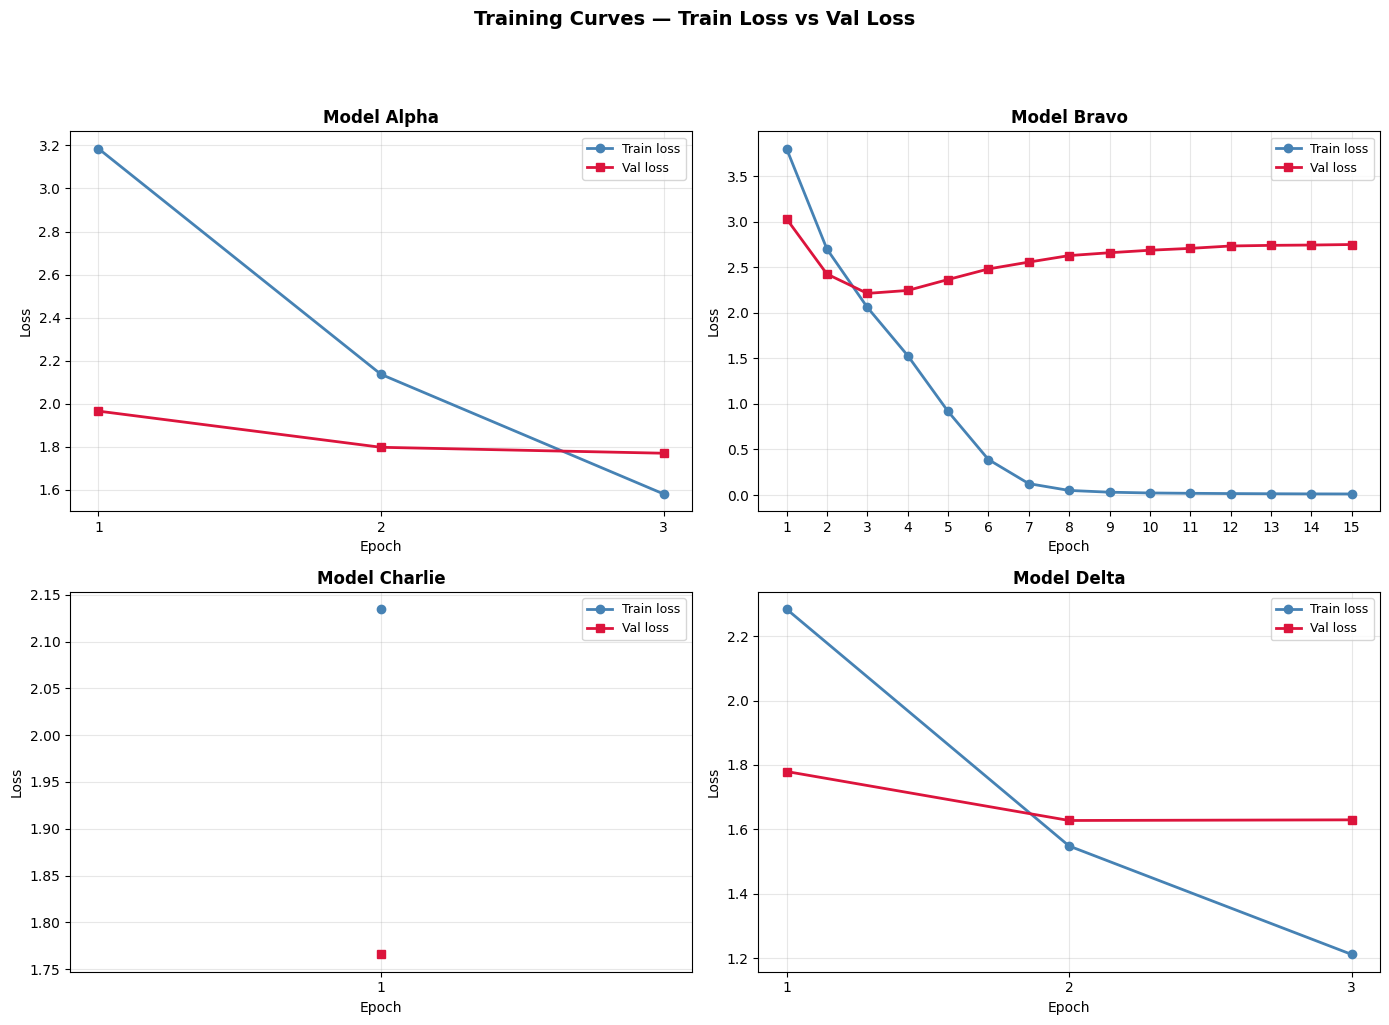

In [14]:
# GUIDED: All 4 models side by side.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training Curves — Train Loss vs Val Loss", fontsize=14, fontweight="bold", y=1.02)

for ax, name in zip(axes.flat, ["Alpha", "Bravo", "Charlie", "Delta"]):
    key = name.lower()
    log = training_logs[key]
    epochs = [e["epoch"] for e in log["epochs"]]
    train_losses = [e["train_loss"] for e in log["epochs"]]
    val_losses = [e["val_loss"] for e in log["epochs"]]

    ax.plot(epochs, train_losses, "o-", color="steelblue", linewidth=2, markersize=6, label="Train loss")
    ax.plot(epochs, val_losses, "s-", color="crimson", linewidth=2, markersize=6, label="Val loss")
    ax.set_title(f"Model {name}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(epochs)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**Study all 4 curves. For each model, ask yourself:**

- Is the training loss still dropping at the end? Or has it flattened?
- What is the val loss doing — decreasing, flat, or rising?
- Is there a gap between train loss and val loss? What does that mean?
- How many epochs did this model train for?

**Were your predictions from Part 4 correct?**

YOUR OBSERVATIONS:

I swapped the diagnoses for under- and overtraining basically, with accuracy misleading me in this regard.


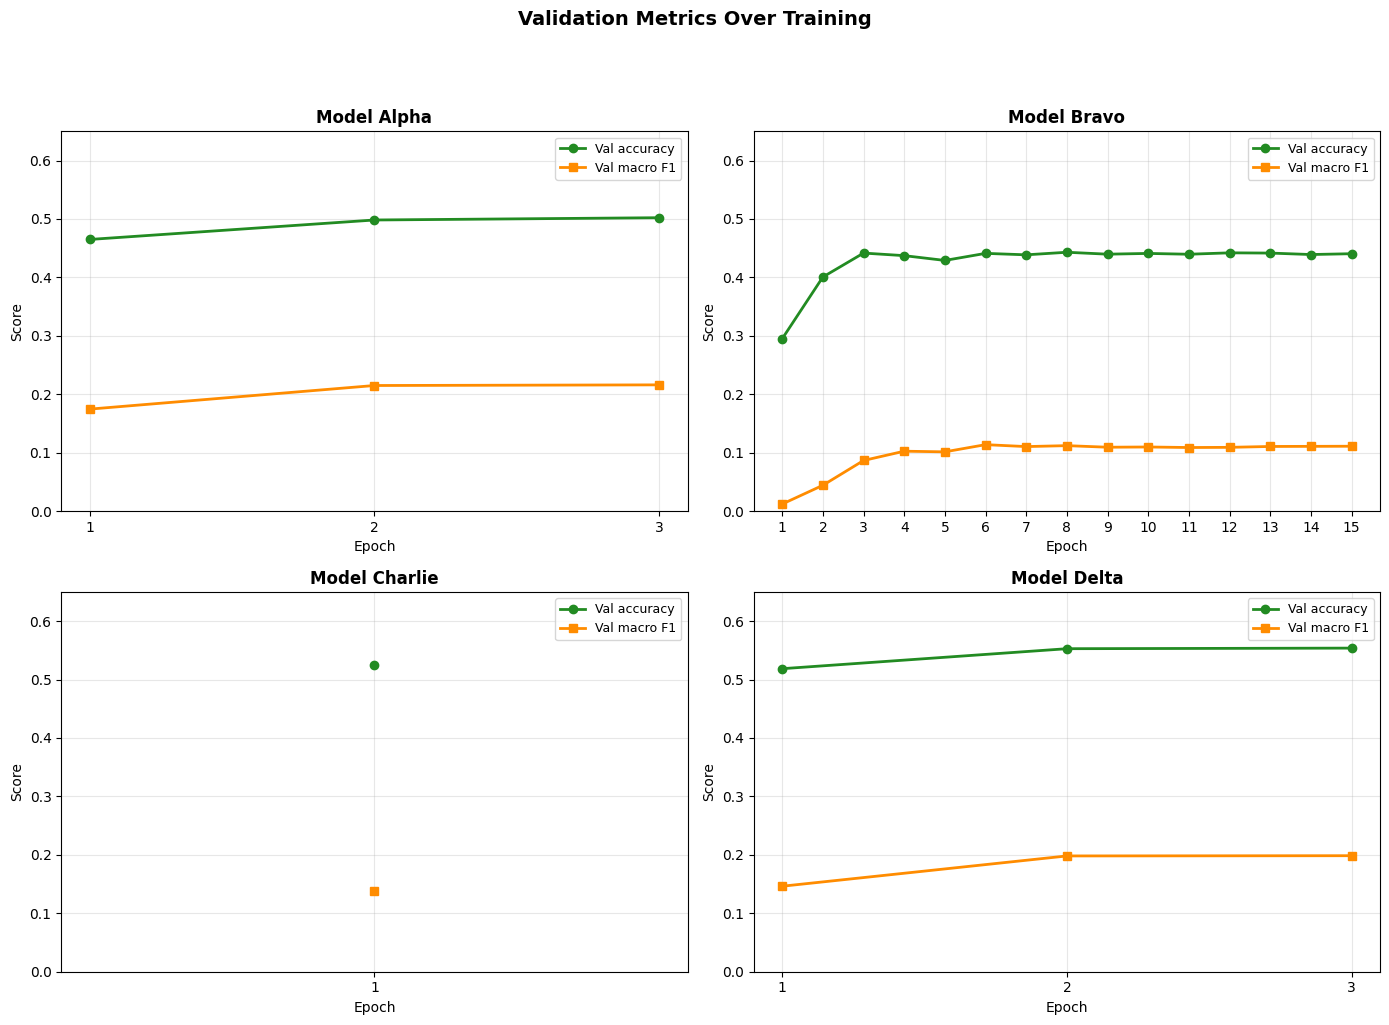

In [15]:
# GUIDED: Val accuracy and macro F1 over training
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Validation Metrics Over Training", fontsize=14, fontweight="bold", y=1.02)

for ax, name in zip(axes.flat, ["Alpha", "Bravo", "Charlie", "Delta"]):
    key = name.lower()
    log = training_logs[key]
    epochs = [e["epoch"] for e in log["epochs"]]
    accs = [e["val_accuracy"] for e in log["epochs"]]
    f1s = [e["val_macro_f1"] for e in log["epochs"]]

    ax.plot(epochs, accs, "o-", color="forestgreen", linewidth=2, markersize=6, label="Val accuracy")
    ax.plot(epochs, f1s, "s-", color="darkorange", linewidth=2, markersize=6, label="Val macro F1")
    ax.set_title(f"Model {name}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 0.65)
    ax.set_xticks(epochs)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---
## Part 6: Per-Class F1 — Where Do the Models Differ? (~10 min)

The comparison table shows aggregate metrics. But the interesting question
is: which specific classes does each model get right or wrong? Let's look
at the classes where the models disagree most.
---

In [16]:
# GUIDED: Compute per-class F1 for all models, find where they differ most
train_ds_raw, _, _ = load_course_data(tokenizer=None)
train_label_counts = Counter(train_ds_raw["label"])

per_class = []
for class_id in range(NUM_LABELS):
    row = {"class": LABEL_LIST[class_id], "class_id": class_id,
           "train_count": train_label_counts.get(class_id, 0)}
    for name in ["Alpha", "Bravo", "Charlie", "Delta"]:
        preds = results[name]["preds"]
        labels = results[name]["labels"]
        row[name] = round(f1_score(labels == class_id, preds == class_id, zero_division=0), 3)
    per_class.append(row)

per_class_df = pd.DataFrame(per_class)

# Find the 10 classes with the largest F1 difference between any two models
per_class_df["max_f1"] = per_class_df[["Alpha", "Bravo", "Charlie", "Delta"]].max(axis=1)
per_class_df["min_f1"] = per_class_df[["Alpha", "Bravo", "Charlie", "Delta"]].min(axis=1)
per_class_df["spread"] = per_class_df["max_f1"] - per_class_df["min_f1"]
top_spread = per_class_df.nlargest(10, "spread")

print("10 classes where the models disagree most:")
print(f"{'Class':<45} {'Train':>5}  {'Alpha':>7}  {'Bravo':>7}  {'Charlie':>7}  {'Delta':>7}")
print("-" * 95)
for _, row in top_spread.iterrows():
    print(f"{row['class'][:43]:<45} {row['train_count']:>5}  {row['Alpha']:>7.3f}  "
          f"{row['Bravo']:>7.3f}  {row['Charlie']:>7.3f}  {row['Delta']:>7.3f}")

10 classes where the models disagree most:
Class                                         Train    Alpha    Bravo  Charlie    Delta
-----------------------------------------------------------------------------------------------
Balance transfer fee                             42    0.714    0.000    0.000    0.615
Wrong amount charged or received                 28    0.500    0.000    0.000    0.000
Credit line increase/decrease                    62    0.333    0.000    0.000    0.429
Advertising and marketing                       128    0.400    0.000    0.286    0.231
Getting a credit card                           169    0.125    0.000    0.091    0.375
Was approved for a loan, but didn't receive      34    0.364    0.000    0.000    0.222
Using a debit or ATM card                       217    0.351    0.146    0.059    0.419
Unsolicited issuance of credit card             106    0.300    0.000    0.133    0.353
Cash advance fee                                 14    0.333    0.000

**What patterns do you see?**

- Which model tends to do best on these classes? Which does worst?
- How many training examples do these classes have?
- What might explain why the models disagree on these specific classes?

YOUR ANSWER:

1. Alpha performs the best in general.

2. Very few compared to the overall training test size.

3. Their very low frequency and lack of weighting in some of the models.

---
## Part 7: Form Your Hypotheses (~10 min)

All 4 models use the same architecture (ModernBERT-base) and the same
dataset. They differ in **three dimensions only:**

- **Training duration** (number of epochs)
- **Data quantity** (full dataset vs subset)
- **Loss function** (standard vs class-weighted)

No other variables were changed. Based on the comparison table, training
curves, and per-class analysis, write your hypothesis for each model.

**Write all 4 hypotheses. Eduardo will reveal the answers when everyone
is ready.**
---

### Part 7 Answer Table (Fill This In)

Use this table to summarize your hypothesis for each model:

| Model | Duration (epochs) | Data quantity (full/subset) | Loss function (standard/class-weighted) | Evidence |
|---|---|---|---|---|
| Alpha | 3 | full | weighted |  |
| Bravo | 15 | subset | standard |  |
| Charlie | 1 | subset | standard |  |
| Delta | 3 | full | weighted |  |

### Model Alpha

**My hypothesis:**



**Evidence:**

YOUR ANSWER:



### Model Bravo

**My hypothesis:** What was the training configuration?

**Evidence:**

YOUR ANSWER:



### Model Charlie

**My hypothesis:** What was the training configuration?

**Evidence:**

YOUR ANSWER:



### Model Delta

**My hypothesis:** What was the training configuration?

**Evidence:**

YOUR ANSWER:



---
## Part 8: Bug Hunt (~10 min)

The code below trains a **fresh** model (not one of the 4 you just analyzed)
on a 10K subset for 3 epochs. In your Week 1 homework, training loss
dropped from ~3.0 to ~1.5 over 3 epochs. This code should do the same.

**Run it and watch the output.** Something is wrong.

After running, find the bug and explain what's happening.
---

In [22]:
# BUG HUNT: Run this cell. Watch the loss. Something is wrong.
from torch.amp import GradScaler
from sklearn.model_selection import train_test_split

# Load full training set for the subset
train_ds_tok, _, _ = load_course_data(tokenizer=tokenizer, max_length=MAX_LENGTH)

# 10K stratified subset
all_idx = list(range(len(train_ds_tok)))
sub_idx, _ = train_test_split(all_idx, train_size=10_000, stratify=train_ds_tok["label"], random_state=42)
bug_subset = train_ds_tok.select(sub_idx)

bug_model = AutoModelForSequenceClassification.from_pretrained(
    "answerdotai/ModernBERT-base",
    num_labels=NUM_LABELS,
    attn_implementation="sdpa",
    id2label=ID_TO_LABEL,
    label2id=LABEL_TO_ID,
).to(device)

bug_optimizer = torch.optim.AdamW(bug_model.parameters(), lr=2e-5, weight_decay=0.01)
bug_scaler = GradScaler("cuda", enabled=(AMP_DTYPE == torch.float16))
bug_loss_fn = nn.CrossEntropyLoss()

bug_train_loader = DataLoader(ComplaintDataset(bug_subset), batch_size=32, shuffle=True)

for epoch in range(1, 4):
    bug_model.train()
    running_loss, n = 0.0, 0
    for batch in bug_train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        bug_optimizer.zero_grad()
        with autocast("cuda", dtype=AMP_DTYPE, enabled=(device.type == "cuda")):
            logits = bug_model(input_ids=input_ids, attention_mask=attention_mask).logits
            loss = bug_loss_fn(logits, labels)

        bug_scaler.scale(loss).backward()
        bug_scaler.step(bug_optimizer)
        bug_scaler.update()
        running_loss += loss.item() * labels.size(0)
        n += labels.size(0)

    print(f"  Epoch {epoch}: loss={running_loss/n:.4f}")

# Clean up
del bug_model, bug_optimizer, bug_scaler
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1: loss=2.8147
  Epoch 2: loss=1.9942
  Epoch 3: loss=1.5297


In Week 1, training loss dropped steadily over epochs.
Here it stays high and barely decreases. Something is preventing
the model from learning.

**Look at the training loop above. Find the bug and explain:**
1. Which line is wrong?
2. Why does it prevent the model from learning?
3. How would you fix it?

YOUR ANSWER:

We are applying softmax on the raw logits before passing them to the loss function which uses cross enthropy. It originally expects raw logits and does the conversion to probs, so this extra steps in the buggy code squashes the logits and makes the gradient less.


---
## Part 9: Synthesis (~9 min)
---

**Now that you know what each model's configuration was (from Eduardo's
reveal), answer these questions:**

1. Which intervention had the largest effect on macro F1?

2. One model has lower accuracy but higher F1 than another. What explains
   this trade-off?

3. One model trained for many more epochs than the others but performed
   worse. What does this tell you about the relationship between training
   time and data quantity?

4. If you could only make ONE change to the vanilla baseline model, what
   would it be and why?

YOUR ANSWERS:

1. Weighting.

2. Alpha has it, because it has weighting.

3. Finding a good loss function is more important than the amount of data.

4. Weighting.


**Reflection: Where were you wrong?**

Look back at your hypotheses from Part 7. Which one was furthest off?
What evidence was available that you underweighted or missed?

YOUR ANSWER:

About which model has been over- or undertrained.

In [ ]:
# GUIDED: Save comparison table for homework reference
save_path = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
comparison_df.to_csv(save_path / "week2_lab_results.csv", index=False)
print(f"Saved to {save_path / 'week2_lab_results.csv'}")

## What's next

In the homework, **you train your own models.** You know what the
interventions do — you saw the results today. Now reproduce them on
full data and go deeper: batch size experiments, early stopping,
confusion matrix analysis, and the question of how much you can
trust your validation metrics.